In [1]:
import os, findspark
os.environ["JAVA_HOME"] = r"C:\java"
os.environ["HADOOP_HOME"] = r"C:\hadoop"   # opcional, por winutils
findspark.init(r"C:\spark")

## 1. Incializando Spark

### 1.1. Crear la SparkSession

In [2]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("Airbnb Proyecto")
    .master("local[*]")
    .config("spark.executor.memory", "16g")
    .config("spark.driver.memory", "16g")
    .getOrCreate()
)

print("Versión de Spark:", spark.version)

Versión de Spark: 3.5.7


### 1.2. Lectura de los CSV con Spark

In [3]:
# Rutas (cámbialas según tu estructura)
path_listings = "listings.csv"
path_reviews = "reviews.csv"
path_neighbourhoods = "neighbourhoods.csv"

listings_df = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)   # detecta tipos automáticamente (luego refinamos en limpieza)
    .csv(path_listings)
)

reviews_df = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv(path_reviews)
)

neigh_df = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv(path_neighbourhoods)
)

Comprobamos que se leyeron bien:

In [4]:
listings_df.printSchema()
reviews_df.printSchema()
neigh_df.printSchema()

root
 |-- id: string (nullable = true)
 |-- name: string (nullable = true)
 |-- host_id: string (nullable = true)
 |-- host_name: string (nullable = true)
 |-- neighbourhood_group: string (nullable = true)
 |-- neighbourhood: string (nullable = true)
 |-- latitude: string (nullable = true)
 |-- longitude: string (nullable = true)
 |-- room_type: string (nullable = true)
 |-- price: string (nullable = true)
 |-- minimum_nights: string (nullable = true)
 |-- number_of_reviews: string (nullable = true)
 |-- last_review: string (nullable = true)
 |-- reviews_per_month: string (nullable = true)
 |-- calculated_host_listings_count: string (nullable = true)
 |-- availability_365: double (nullable = true)
 |-- number_of_reviews_ltm: integer (nullable = true)
 |-- license: string (nullable = true)

root
 |-- listing_id: long (nullable = true)
 |-- date: date (nullable = true)

root
 |-- neighbourhood_group: string (nullable = true)
 |-- neighbourhood: string (nullable = true)



In [5]:
listings_df.show(5, truncate=False)
reviews_df.show(5, truncate=False)
neigh_df.show(5, truncate=False)

+-----+-----------------------------------+-------+---------------+-------------------+-------------+---------+---------+---------------+-----+--------------+-----------------+-----------+-----------------+------------------------------+----------------+---------------------+-------+
|id   |name                               |host_id|host_name      |neighbourhood_group|neighbourhood|latitude |longitude|room_type      |price|minimum_nights|number_of_reviews|last_review|reviews_per_month|calculated_host_listings_count|availability_365|number_of_reviews_ltm|license|
+-----+-----------------------------------+-------+---------------+-------------------+-------------+---------+---------+---------------+-----+--------------+-----------------+-----------+-----------------+------------------------------+----------------+---------------------+-------+
|65058|Dpto amoblado centro historico     |318016 |Patricio       |NULL               |Recoleta     |-33.43049|-70.64079|Private room   |NULL |2 

## 2. Exploracion de los datos

### 2.1. Función general de resumen
Podemos definir una función auxiliar para no repetir tanto código:

In [6]:
from pyspark.sql import functions as F

def resumen_df(df, nombre):
    print(f"\n===== Resumen de {nombre} =====")
    
    # 1. Número de registros y columnas
    filas = df.count()
    columnas = len(df.columns)
    print(f"Filas: {filas}")
    print(f"Columnas: {columnas}")
    
    # 2. Esquema
    print("\nSchema:")
    df.printSchema()
    
    # 3. Muestra de datos
    print("\nMuestra de 5 filas:")
    df.show(5, truncate=False)
    
    # 4. Conteo de nulos por columna
    print("\nConteo de valores nulos por columna:")
    nulos = df.select([
        F.count(F.when(F.col(c).isNull() | (F.col(c) == ""), c)).alias(c)
        for c in df.columns
    ])
    nulos.show(truncate=False)
    
    # 5. Conteo aproximado de distintos por columna (útil para variables categóricas)
    print("\nNúmero de valores distintos por columna (approx_count_distinct):")
    distintos = df.select([
        F.approx_count_distinct(F.col(c)).alias(c)
        for c in df.columns
    ])
    distintos.show(truncate=False)

In [7]:
resumen_df(listings_df, "LISTINGS")


===== Resumen de LISTINGS =====
Filas: 15143
Columnas: 18

Schema:
root
 |-- id: string (nullable = true)
 |-- name: string (nullable = true)
 |-- host_id: string (nullable = true)
 |-- host_name: string (nullable = true)
 |-- neighbourhood_group: string (nullable = true)
 |-- neighbourhood: string (nullable = true)
 |-- latitude: string (nullable = true)
 |-- longitude: string (nullable = true)
 |-- room_type: string (nullable = true)
 |-- price: string (nullable = true)
 |-- minimum_nights: string (nullable = true)
 |-- number_of_reviews: string (nullable = true)
 |-- last_review: string (nullable = true)
 |-- reviews_per_month: string (nullable = true)
 |-- calculated_host_listings_count: string (nullable = true)
 |-- availability_365: double (nullable = true)
 |-- number_of_reviews_ltm: integer (nullable = true)
 |-- license: string (nullable = true)


Muestra de 5 filas:
+-----+-----------------------------------+-------+---------------+-------------------+-------------+---------

In [8]:
resumen_df(reviews_df, "REVIEWS")


===== Resumen de REVIEWS =====
Filas: 454372
Columnas: 2

Schema:
root
 |-- listing_id: long (nullable = true)
 |-- date: date (nullable = true)


Muestra de 5 filas:
+----------+----------+
|listing_id|date      |
+----------+----------+
|88944     |2011-10-21|
|88944     |2012-01-29|
|88944     |2012-04-03|
|88944     |2012-06-03|
|88944     |2012-07-06|
+----------+----------+
only showing top 5 rows


Conteo de valores nulos por columna:
+----------+----+
|listing_id|date|
+----------+----+
|0         |0   |
+----------+----+


Número de valores distintos por columna (approx_count_distinct):
+----------+----+
|listing_id|date|
+----------+----+
|11364     |4319|
+----------+----+



In [9]:
resumen_df(neigh_df, "NEIGHBOURHOODS")


===== Resumen de NEIGHBOURHOODS =====
Filas: 32
Columnas: 2

Schema:
root
 |-- neighbourhood_group: string (nullable = true)
 |-- neighbourhood: string (nullable = true)


Muestra de 5 filas:
+-------------------+----------------+
|neighbourhood_group|neighbourhood   |
+-------------------+----------------+
|NULL               |Cerrillos       |
|NULL               |Cerro Navia     |
|NULL               |Conchalí        |
|NULL               |El Bosque       |
|NULL               |Estación Central|
+-------------------+----------------+
only showing top 5 rows


Conteo de valores nulos por columna:
+-------------------+-------------+
|neighbourhood_group|neighbourhood|
+-------------------+-------------+
|32                 |0            |
+-------------------+-------------+


Número de valores distintos por columna (approx_count_distinct):
+-------------------+-------------+
|neighbourhood_group|neighbourhood|
+-------------------+-------------+
|0                  |32           |
+-

### 2.2. Exploración específica de cada dataset

#### 2.2.1. `listings_df` (propiedades)
#### a) Número de listings y duplicados en `id`

In [10]:
total_listings = listings_df.count()
distinct_ids = listings_df.select("id").distinct().count()

print("Total registros en listings:", total_listings)
print("IDs únicos:", distinct_ids)
print("Registros duplicados por id:", total_listings - distinct_ids)

Total registros en listings: 15143
IDs únicos: 15141
Registros duplicados por id: 2


In [11]:
from pyspark.sql.window import Window

w = Window.partitionBy("id")
listings_dups = listings_df.withColumn("count_id", F.count("*").over(w)) \
                           .filter(F.col("count_id") > 1)

listings_dups.show(20, truncate=False)

+-------------+---------+--------------+---------+-------------------+------------------+------------------+---------------+---------+-----+--------------+-----------------+-----------+-----------------+------------------------------+----------------+---------------------+-------+--------+
|id           |name     |host_id       |host_name|neighbourhood_group|neighbourhood     |latitude          |longitude      |room_type|price|minimum_nights|number_of_reviews|last_review|reviews_per_month|calculated_host_listings_count|availability_365|number_of_reviews_ltm|license|count_id|
+-------------+---------+--------------+---------+-------------------+------------------+------------------+---------------+---------+-----+--------------+-----------------+-----------+-----------------+------------------------------+----------------+---------------------+-------+--------+
|“Román Díaz”"|483459810|Cindy Carolina|NULL     |Providencia        |-33.43541276526962|-70.62062479555607|Private room   |320

#### b) Distribución por `neighbourhood` y `room_type`

In [12]:
print("\nTop 20 barrios con más listings:")
listings_df.groupBy("neighbourhood") \
    .count() \
    .orderBy(F.col("count").desc()) \
    .show(20, truncate=False)


Top 20 barrios con más listings:
+----------------+-----+
|neighbourhood   |count|
+----------------+-----+
|Santiago        |5453 |
|Providencia     |2717 |
|Las Condes      |2417 |
|Ñuñoa           |1178 |
|Lo Barnechea    |737  |
|Vitacura        |344  |
|Recoleta        |295  |
|Estación Central|274  |
|La Florida      |211  |
|Macul           |169  |
|La Reina        |162  |
|San Miguel      |161  |
|Independencia   |124  |
|Peñalolén       |109  |
|Maipú           |107  |
|NULL            |101  |
|Pudahuel        |90   |
|San Joaquín     |84   |
|La Cisterna     |79   |
|Huechuraba      |57   |
+----------------+-----+
only showing top 20 rows



In [13]:
print("\nDistribución por tipo de habitación:")
listings_df.groupBy("room_type") \
    .count() \
    .orderBy(F.col("count").desc()) \
    .show(truncate=False)


Distribución por tipo de habitación:
+---------------+-----+
|room_type      |count|
+---------------+-----+
|Entire home/apt|11051|
|Private room   |3848 |
|NULL           |101  |
|Shared room    |31   |
|Hotel room     |30   |
|43000          |3    |
|40000          |3    |
|25000          |3    |
|30000          |2    |
|35000          |2    |
|60000          |2    |
|45000          |2    |
|93571          |1    |
|154714         |1    |
|51429          |1    |
|17900          |1    |
|-70.5868885    |1    |
|23476          |1    |
|56958          |1    |
|33428          |1    |
+---------------+-----+
only showing top 20 rows



#### c) Estadísticos básicos de variables numéricas

In [14]:
listings_df.select(
    "price",
    "minimum_nights",
    "number_of_reviews",
    "availability_365"
).describe().show()

+-------+-----------------+------------------+-----------------+------------------+
|summary|            price|    minimum_nights|number_of_reviews|  availability_365|
+-------+-----------------+------------------+-----------------+------------------+
|  count|            13074|             15048|            15038|             15051|
|   mean|84984.96500036577|23.036155788913998|38.00240464898804|236.64728190817888|
| stddev|988096.5631083626|  902.738499102664|703.4525380869077| 131.7214510396602|
|    min|        -70.61423|                 0|                0|               0.0|
|    max|     Private room|   Entire home/apt|               99|             365.0|
+-------+-----------------+------------------+-----------------+------------------+



### 2.2.2. `reviews_df`
Columnas típicas: `listing_id`, `date`

#### a) Número de reseñas y duplicados

In [15]:
total_reviews = reviews_df.count()
distinct_reviews = reviews_df.select("listing_id", "date").distinct().count()

print("Total registros en reviews:", total_reviews)
print("Registros únicos (listing_id, date):", distinct_reviews)
print("Registros completamente duplicados:", total_reviews - distinct_reviews)

Total registros en reviews: 454372
Registros únicos (listing_id, date): 452609
Registros completamente duplicados: 1763


#### b) Rango de fechas de las reseñas

In [16]:
reviews_df.select(
    F.min("date").alias("fecha_min"),
    F.max("date").alias("fecha_max")
).show()

+----------+----------+
| fecha_min| fecha_max|
+----------+----------+
|2010-11-13|2024-12-26|
+----------+----------+



#### c) Reseñas por año y/o por mes

In [17]:
reviews_df = reviews_df.withColumn("year", F.year("date"))

reviews_df.groupBy("year") \
    .count() \
    .orderBy("year") \
    .show()

+----+------+
|year| count|
+----+------+
|2010|     1|
|2011|    31|
|2012|   116|
|2013|   333|
|2014|   791|
|2015|  2361|
|2016|  6057|
|2017| 12462|
|2018| 20577|
|2019| 30300|
|2020| 16108|
|2021| 29194|
|2022| 60748|
|2023| 98305|
|2024|176988|
+----+------+



### 2.2.3. `neigh_df`
Columnas: `neighbourhood_group`, `neighbourhood`

#### a) Número de barrios distintos

In [18]:
print("Número de filas en neighbourhoods:", neigh_df.count())
neigh_df.select("neighbourhood").distinct().show(50, truncate=False)

Número de filas en neighbourhoods: 32
+-------------------+
|neighbourhood      |
+-------------------+
|Estación Central   |
|Lo Prado           |
|Pudahuel           |
|Quinta Normal      |
|Lo Barnechea       |
|Pedro Aguirre Cerda|
|Renca              |
|Conchalí           |
|La Reina           |
|Cerro Navia        |
|San Ramón          |
|Quilicura          |
|La Pintana         |
|Huechuraba         |
|La Granja          |
|Vitacura           |
|Macul              |
|Ñuñoa              |
|La Cisterna        |
|Maipú              |
|San Joaquín        |
|San Miguel         |
|El Bosque          |
|La Florida         |
|Las Condes         |
|Independencia      |
|Lo Espejo          |
|Recoleta           |
|Santiago           |
|Cerrillos          |
|Peñalolén          |
|Providencia        |
+-------------------+



#### b) Comprobar coherencia con `listings`
Ver si hay barrios en `listings` que no están en `neighbourhoods`:

In [19]:
neigh_listings = listings_df.select("neighbourhood").distinct()
neigh_ref = neigh_df.select("neighbourhood").distinct()

neigh_missing = neigh_listings.join(
    neigh_ref,
    on="neighbourhood",
    how="left_anti"
)

print("Barrios que existen en listings y no en neighbourhoods:")
neigh_missing.show(50, truncate=False)

Barrios que existen en listings y no en neighbourhoods:
+-------------------+
|neighbourhood      |
+-------------------+
|-33.4541533        |
|-33.44458          |
|-33.35375          |
|-33.4295424        |
|-33.31933          |
|-33.53545          |
|-33.46581814419182 |
|-33.44748          |
|-33.40972          |
|-33.52349          |
|-33.43284          |
|-33.53764          |
|-33.44599          |
|-33.43372          |
|-33.3582209        |
|-33.53603          |
|Daniela            |
|-33.34693          |
|-33.36404137244665 |
|-33.47169240941255 |
|-33.5058592        |
|-33.4379596        |
|-33.53656986044053 |
|-33.4379882        |
|Monica             |
|-33.38383          |
|-33.4477138        |
|-33.41876          |
|-33.43315          |
|-33.45004          |
|-33.43662          |
|-33.412430595703356|
|-33.43541276526962 |
|-33.43551          |
|-33.44176          |
|-33.4248774        |
|-33.451617029600165|
|-33.44260168917117 |
|-33.45677          |
|-33.44432          

## 3. Limpieza de Datos

### 3.1. Punto de partida

In [20]:
from pyspark.sql import functions as F
from pyspark.sql import Window

listings = listings_df
reviews  = reviews_df
neigh    = neigh_df

### 3.2. Corrección de tipos de datos

#### 3.2.1. Precio: limpiar texto → numérico
InsideAirbnb suele traer `price` como texto tipo `"$45,000"`.

In [21]:
# 1) Limpieza de string y conversión a numérico (moneda original: CLP normalmente)
listings = listings.withColumn(
    "price_clp",
    F.regexp_replace(F.col("price"), r"[\$,]", "").cast("double")
)

#### 3.2.2. Conversión a USD (normalización de moneda)

In [22]:
# Tipo de cambio fijo elegido para el proyecto
CLP_PER_USD = 930.0  # ejemplo

listings = listings.withColumn(
    "price_usd",
    (F.col("price_clp") / F.lit(CLP_PER_USD))
)

#### 3.2.3. Otras columnas numéricas
Forzamos tipos para asegurar consistencia:

In [23]:
listings = (listings
    .withColumn("minimum_nights", F.col("minimum_nights").cast("int"))
    .withColumn("number_of_reviews", F.col("number_of_reviews").cast("int"))
    .withColumn("availability_365", F.col("availability_365").cast("int"))
    .withColumn("calculated_host_listings_count", F.col("calculated_host_listings_count").cast("int"))
    .withColumn("number_of_reviews_ltm", F.col("number_of_reviews_ltm").cast("int"))
    .withColumn("latitude", F.col("latitude").cast("double"))
    .withColumn("longitude", F.col("longitude").cast("double"))
)

#### 3.2.4. Fechas

In [24]:
listings = listings.withColumn(
    "last_review",
    F.to_date("last_review", "yyyy-MM-dd")
)

reviews = reviews.withColumn(
    "date",
    F.to_date("date", "yyyy-MM-dd")
)

### 3.3. Filtrar registros inválidos / absurdos
#### 3.3.1. Filtros básicos de negocio

In [25]:
listings = listings.filter(F.col("price_usd").isNotNull())

# Noches mínimas razonables (ej. 1 a 365)
listings = listings.filter(
    (F.col("minimum_nights") >= 1) &
    (F.col("minimum_nights") <= 365)
)

# Disponibilidad anual entre 0 y 365
listings = listings.filter(
    (F.col("availability_365") >= 0) &
    (F.col("availability_365") <= 365)
)

#### 3.3.2. Tratamiento de outliers de precio (para evitar que distorsionen ML)
Esto recorta el 1% más barato y el 1% más caro, dejando una distribución más saludable para K-Means y regresión

In [26]:
q1, q99 = listings.approxQuantile("price_usd", [0.01, 0.99], 0.01)
print("P1:", q1, "P99:", q99)

listings = listings.filter(
    (F.col("price_usd") >= q1) &
    (F.col("price_usd") <= q99)
)

P1: 0.001075268817204301 P99: 104223.5311827957


### 3.4. Tratamiento de nulos (pensando en ML)
Decidimos qué campos son obligatorios para el modelos:
- `price_usd` (target)
- `latitude`, `longitude` (para segmentar por zona)
- `neighbourhood`, `room_type`
- `minimum_nights`, `availability_365`
- `number_of_reviews` (métrica de demanda)

In [27]:
cols_obligatorias = [
    "price_usd", "latitude", "longitude",
    "neighbourhood", "room_type",
    "minimum_nights", "availability_365",
    "number_of_reviews"
]

listings = listings.dropna(subset=cols_obligatorias)

In [28]:
# Si reviews_per_month es nulo, asumimos 0
listings = listings.fillna({"reviews_per_month": 0.0})

### 3.5. Eliminación de duplicados
Clave para ML: un listing = una fila.

In [29]:
w = Window.partitionBy("id").orderBy(F.col("last_review").desc_nulls_last())

listings = (listings
    .withColumn("rn", F.row_number().over(w))
    .filter(F.col("rn") == 1)
    .drop("rn")
)

### 3.6. Validación geográfica (coordenadas de Santiago)
Definimos un bounding box aproximado para Santiago:

In [30]:
listings = listings.filter(
    (F.col("latitude").between(-33.7, -33.3)) &
    (F.col("longitude").between(-70.9, -70.4))
)

### 3.7. Coherencia con tabla de neighbourhoods
Nos aseguramos de que los barrios usados en `listings` existan en `neigh`:

In [31]:
neigh_validos = neigh.select("neighbourhood").distinct()

listings = listings.join(
    neigh_validos,
    on="neighbourhood",
    how="inner"   # dejamos solo los barrios válidos
)

### 3.8. Limpieza básica de reviews coherente con listings
Queremos quedarnos solo con reseñas de los listings que sobrevivieron la limpieza:

In [32]:
reviews = reviews.join(
    listings.select("id").withColumnRenamed("id", "listing_id"),
    on="listing_id",
    how="inner"
)

#### 3.8.1 Eliminar nulos en claves esenciales

In [33]:
reviews = reviews.dropna(subset=["listing_id", "date"])

#### 3.8.2 Eliminar duplicados exactos por (listing_id, date)

In [34]:
reviews = reviews.dropDuplicates(["listing_id", "date"])

### 3.9. Verificación final de la limpieza
Para cerrar el Paso 3, conviene sacar un pequeño resumen:

In [35]:
print("Filas finales en listings:", listings.count())
listings.select(
    "price_usd", "minimum_nights", "number_of_reviews", "availability_365"
).describe().show()

# Distribución final de room_type y neighbourhood
listings.groupBy("room_type").count().show()
listings.groupBy("neighbourhood").count().orderBy(F.col("count").desc()).show(10)

Filas finales en listings: 12478
+-------+------------------+------------------+-----------------+------------------+
|summary|         price_usd|    minimum_nights|number_of_reviews|  availability_365|
+-------+------------------+------------------+-----------------+------------------+
|  count|             12478|             12478|            12478|             12478|
|   mean| 80.62130855682211| 4.184164128866805|33.86343965379067| 263.8838756210931|
| stddev|1084.8520914754572|15.880345220961967|61.72587088948858|110.40540561705585|
|    min| 8.346236559139784|                 1|                0|                 0|
|    max| 104223.5311827957|               365|             1227|               365|
+-------+------------------+------------------+-----------------+------------------+

+---------------+-----+
|      room_type|count|
+---------------+-----+
|    Shared room|   21|
|     Hotel room|   22|
|Entire home/apt| 9592|
|   Private room| 2843|
+---------------+-----+

+-------

In [36]:
# Revision limpieza de reviews
print("Filas finales en reviews:", reviews.count())
reviews.select(
    F.min("date").alias("fecha_min_reviews"),
    F.max("date").alias("fecha_max_reviews")
).show()

Filas finales en reviews: 420700
+-----------------+-----------------+
|fecha_min_reviews|fecha_max_reviews|
+-----------------+-----------------+
|       2010-11-13|       2024-12-26|
+-----------------+-----------------+



## 4. Machine Learning

#### 4.1.1 Crear tasa de ocupación aproximada a partir de availability_365

In [37]:
listings_ml = listings.withColumn(
    "occupancy_rate",
    1 - (F.col("availability_365") / F.lit(365.0))
)

#### 4.1.2 Seleccionar columnas relevantes para ML

In [38]:
listings_ml = listings_ml.select(
    "id",
    "neighbourhood",
    "room_type",
    "latitude", "longitude",
    "price_usd",
    "minimum_nights",
    "availability_365",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "occupancy_rate"
).dropna(subset=["price_usd"])

print("Filas en listings_ml:", listings_ml.count())
listings_ml.printSchema()

Filas en listings_ml: 12478
root
 |-- id: string (nullable = true)
 |-- neighbourhood: string (nullable = true)
 |-- room_type: string (nullable = true)
 |-- latitude: double (nullable = true)
 |-- longitude: double (nullable = true)
 |-- price_usd: double (nullable = true)
 |-- minimum_nights: integer (nullable = true)
 |-- availability_365: integer (nullable = true)
 |-- number_of_reviews: integer (nullable = true)
 |-- reviews_per_month: string (nullable = false)
 |-- calculated_host_listings_count: integer (nullable = true)
 |-- occupancy_rate: double (nullable = true)



### 4.2. K-Means: segmentar zonas
Usamos `listings_ml` para crear agregados por `neighbourhood`:

In [39]:
from pyspark.sql import functions as F

zones = (listings_ml
    .groupBy("neighbourhood")
    .agg(
        F.count("*").alias("n_listings"),
        F.mean("price_usd").alias("avg_price_usd"),
        F.mean("reviews_per_month").alias("avg_reviews_per_month"),
        F.mean("number_of_reviews").alias("avg_number_of_reviews"),
        F.mean("occupancy_rate").alias("avg_occupancy_rate")
    )
)

zones.show(10, truncate=False)

+-------------------+----------+------------------+---------------------+---------------------+-------------------+
|neighbourhood      |n_listings|avg_price_usd     |avg_reviews_per_month|avg_number_of_reviews|avg_occupancy_rate |
+-------------------+----------+------------------+---------------------+---------------------+-------------------+
|Estación Central   |239       |84.10107526881718 |1.9225523012552297   |29.87029288702929    |0.30139278959133375|
|Pudahuel           |74        |208.69591688462657|1.8664864864864865   |28.87837837837838    |0.26978896704924105|
|Lo Prado           |8         |30.104032258064517|0.65625              |14.625               |0.15445205479452057|
|Quinta Normal      |41        |34.160870705481244|1.209268292682927    |17.536585365853657   |0.2726361510190445 |
|Lo Barnechea       |136       |163.82084914611   |0.5180882352941177   |13.367647058823529   |0.2886784850926672 |
|Renca              |18        |40.44193548387097 |1.7433333333333332   

#### 4.2.1. Preparación de features para clustering

In [40]:
from pyspark.ml.feature import VectorAssembler, StandardScaler

# Columnas que describen el comportamiento de mercado de cada barrio
zone_feature_cols = [
    "avg_price_usd",
    "avg_reviews_per_month",
    "avg_number_of_reviews",
    "avg_occupancy_rate",
    "n_listings"
]

# 1) Unimos las columnas numéricas en un vector
assembler_zones = VectorAssembler(
    inputCols=zone_feature_cols,
    outputCol="features_unnorm"
)

zones_assembled = assembler_zones.transform(zones)

# 2) Estandarizamos (muy importante para K-Means)
scaler_zones = StandardScaler(
    inputCol="features_unnorm",
    outputCol="features",
    withMean=True,
    withStd=True
)

scaler_zones_model = scaler_zones.fit(zones_assembled)
zones_scaled = scaler_zones_model.transform(zones_assembled)

zones_scaled.select("neighbourhood", "features").show(5, truncate=False)

+----------------+------------------------------------------------------------------------------------------------------+
|neighbourhood   |features                                                                                              |
+----------------+------------------------------------------------------------------------------------------------------+
|Estación Central|[0.07064634465748333,0.6665827651564386,0.6964390729627434,0.39242311022103127,-0.16288982247552233]  |
|Pudahuel        |[1.9692927279442685,0.6069374295142019,0.63027901834224,0.021183624093993377,-0.3272578323319628]     |
|Lo Prado        |[-0.7521910143454913,-0.6805665823459988,-0.3204120783358233,-1.3336403368333116,-0.39300503627453903]|
|Quinta Normal   |[-0.690370624786208,-0.09224084732503803,-0.1262112221560596,0.05462853767845551,-0.3601314343032509] |
|Lo Barnechea    |[1.2854611667291929,-0.827549282281723,-0.40427670430911095,0.24307244663402097,-0.2654953074162094]  |
+----------------+------

#### 4.2.2. Selección del número de clusters (k) con Silhouette

In [41]:
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

evaluator = ClusteringEvaluator(
    featuresCol="features",
    predictionCol="prediction",
    metricName="silhouette"
)

results = []

# Probamos varios k y comparamos la métrica silhouette
for k in range(2, 12):   # puedes cambiar el rango si quieres explorar más
    kmeans_tmp = KMeans(featuresCol="features", k=k, seed=42)
    model_tmp = kmeans_tmp.fit(zones_scaled)
    preds_tmp = model_tmp.transform(zones_scaled)
    silhouette = evaluator.evaluate(preds_tmp)
    results.append((k, silhouette))
    print(f"k = {k}, silhouette = {silhouette}")

# Pasamos los resultados a un DataFrame para mejor visualización
sil_df = spark.createDataFrame(results, ["k", "silhouette"])
sil_df.orderBy("k").show()

k = 2, silhouette = 0.7153429994336874
k = 3, silhouette = 0.4200515929497795
k = 4, silhouette = 0.3660912044877124
k = 5, silhouette = 0.3729423226540192
k = 6, silhouette = 0.35767226405772085
k = 7, silhouette = 0.38144274469262446
k = 8, silhouette = 0.40020965332906416
k = 9, silhouette = 0.42378071336453854
k = 10, silhouette = 0.3418820947202873
k = 11, silhouette = 0.2689556298466664
+---+-------------------+
|  k|         silhouette|
+---+-------------------+
|  2| 0.7153429994336874|
|  3| 0.4200515929497795|
|  4| 0.3660912044877124|
|  5| 0.3729423226540192|
|  6|0.35767226405772085|
|  7|0.38144274469262446|
|  8|0.40020965332906416|
|  9|0.42378071336453854|
| 10| 0.3418820947202873|
| 11| 0.2689556298466664|
+---+-------------------+



Se probó K-Means con k de 2 a 7 y se eligió el valor k = X por presentar el mejor compromiso entre la métrica silhouette y una segmentación interpretable del mercado.

#### 4.2.3. Entrenamiento del modelo K-Means final

In [42]:
best_k = 4  # AJUSTA este valor según la tabla de silhouette

kmeans_final = KMeans(
    featuresCol="features",
    k=best_k,
    seed=42
)

kmeans_model = kmeans_final.fit(zones_scaled)

# Aplicamos el modelo para asignar cada barrio a un cluster
zones_clusters = kmeans_model.transform(zones_scaled)

# Renombramos 'prediction' a algo más expresivo
zones_clusters = zones_clusters.withColumnRenamed("prediction", "demand_cluster")

zones_clusters.select(
    "neighbourhood",
    "demand_cluster",
    "n_listings",
    "avg_price_usd",
    "avg_occupancy_rate"
).orderBy("demand_cluster").show(50, truncate=False)

+-------------------+--------------+----------+------------------+-------------------+
|neighbourhood      |demand_cluster|n_listings|avg_price_usd     |avg_occupancy_rate |
+-------------------+--------------+----------+------------------+-------------------+
|Lo Prado           |0             |8         |30.104032258064517|0.15445205479452057|
|Lo Barnechea       |0             |136       |163.82084914611   |0.2886784850926672 |
|Conchalí           |0             |21        |51.01925243215566 |0.14168297455968695|
|La Reina           |0             |111       |61.97712874164489 |0.29063309885227695|
|San Ramón          |0             |1         |23.655913978494624|0.3397260273972603 |
|La Pintana         |0             |1         |172.04301075268816|0.0                |
|Huechuraba         |0             |43        |60.01497874468619 |0.30474673462886276|
|La Granja          |0             |9         |83.21385902031064 |0.1019786910197869 |
|Maipú              |0             |84     

#### 4.2.4. Resumen e interpretación de los clusters
Aquí generamos una tabla con el “perfil” de cada cluster

In [43]:
zones_summary = (zones_clusters
    .groupBy("demand_cluster")
    .agg(
        F.count("*").alias("n_barrios"),
        F.mean("avg_price_usd").alias("cluster_avg_price_usd"),
        F.mean("avg_reviews_per_month").alias("cluster_avg_reviews_per_month"),
        F.mean("avg_number_of_reviews").alias("cluster_avg_number_of_reviews"),
        F.mean("avg_occupancy_rate").alias("cluster_avg_occupancy_rate"),
        F.mean("n_listings").alias("cluster_n_listings")
    )
    .orderBy("demand_cluster")
)

zones_summary.show(truncate=False)

+--------------+---------+---------------------+-----------------------------+-----------------------------+--------------------------+------------------+
|demand_cluster|n_barrios|cluster_avg_price_usd|cluster_avg_reviews_per_month|cluster_avg_number_of_reviews|cluster_avg_occupancy_rate|cluster_n_listings|
+--------------+---------+---------------------+-----------------------------+-----------------------------+--------------------------+------------------+
|0             |12       |72.96352986729067    |0.5019957389600856           |6.717958001728522            |0.22829010304995537       |42.25             |
|1             |1        |60.161648745519706   |5.043333333333333            |65.66666666666667            |0.15707762557077629       |3.0               |
|2             |3        |86.50628830561175    |1.656400770780456            |37.77857425560635            |0.2746519223712345        |3126.3333333333335|
|3             |15       |84.5449145681509     |1.6092461641912004    

#### 4.2.5. Asignar el cluster a cada anuncio (para usarlo luego en el modelo de precios)

In [44]:
# Nos quedamos con el barrio y el cluster
zones_clusters_small = zones_clusters.select("neighbourhood", "demand_cluster")

# Sumamos el cluster de demanda a cada listing
listings_ml = listings_ml.join(
    zones_clusters_small,
    on="neighbourhood",
    how="left"
)

# Comprobamos
listings_ml.select(
    "neighbourhood", "demand_cluster"
).distinct().orderBy("demand_cluster", "neighbourhood").show(50, truncate=False)

# Vista rápida: cómo se comporta el precio por cluster
listings_ml.groupBy("demand_cluster").agg(
    F.count("*").alias("n_listings"),
    F.mean("price_usd").alias("avg_price_usd"),
    F.mean("occupancy_rate").alias("avg_occupancy_rate")
).orderBy("demand_cluster").show()

+-------------------+--------------+
|neighbourhood      |demand_cluster|
+-------------------+--------------+
|Cerrillos          |0             |
|Conchalí           |0             |
|El Bosque          |0             |
|Huechuraba         |0             |
|La Granja          |0             |
|La Pintana         |0             |
|La Reina           |0             |
|Lo Barnechea       |0             |
|Lo Prado           |0             |
|Maipú              |0             |
|Peñalolén          |0             |
|San Ramón          |0             |
|Cerro Navia        |1             |
|Las Condes         |2             |
|Providencia        |2             |
|Santiago           |2             |
|Estación Central   |3             |
|Independencia      |3             |
|La Cisterna        |3             |
|La Florida         |3             |
|Macul              |3             |
|Pedro Aguirre Cerda|3             |
|Pudahuel           |3             |
|Quilicura          |3             |
|

### 4.3. Predicción del precio de las propiedades
#### 4.3.1. Definir columnas para el modelo y limpiar posibles nulos

In [45]:
from pyspark.sql import functions as F

# Aseguramos que demand_cluster sea entero
listings_ml = listings_ml.withColumn(
    "demand_cluster",
    F.col("demand_cluster").cast("int")
)

# Columnas numéricas que usaremos como features
numeric_cols = [
    "minimum_nights",
    "availability_365",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "occupancy_rate",
    "latitude",
    "longitude",
    "demand_cluster"
]

# Columnas categóricas
cat_cols = [
    "room_type",
    "neighbourhood"
]

# Eliminamos filas con nulos en features o en la variable objetivo
listings_ml_model = listings_ml.dropna(
    subset=numeric_cols + cat_cols + ["price_usd"]
)

print("Filas disponibles para modelado:", listings_ml_model.count())
listings_ml_model.select("price_usd").describe().show()

Filas disponibles para modelado: 12478
+-------+------------------+
|summary|         price_usd|
+-------+------------------+
|  count|             12478|
|   mean| 80.62130855682211|
| stddev|1084.8520914754572|
|    min| 8.346236559139784|
|    max| 104223.5311827957|
+-------+------------------+



#### 4.3.2. Transformaciones: StringIndexer, OneHotEncoder, VectorAssembler

In [46]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler

# Indexadores para variables categóricas
indexers = [
    StringIndexer(
        inputCol=c,
        outputCol=c + "_idx",
        handleInvalid="keep"      # importante por si aparece una categoría rara en test
    )
    for c in cat_cols
]

# One-hot encoding
encoder = OneHotEncoder(
    inputCols=[c + "_idx" for c in cat_cols],
    outputCols=[c + "_ohe" for c in cat_cols]
)

# Columnas finales de features: numéricas + OHE
feature_cols = numeric_cols + [c + "_ohe" for c in cat_cols]

assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features"
)

In [47]:
listings_ml_model = listings_ml.dropna(
    subset=numeric_cols + cat_cols + ["price_usd"]
)

# Reforzamos los tipos numéricos aquí también
listings_ml_model = (listings_ml_model
    .withColumn("minimum_nights", F.col("minimum_nights").cast("double"))
    .withColumn("availability_365", F.col("availability_365").cast("double"))
    .withColumn("number_of_reviews", F.col("number_of_reviews").cast("double"))
    .withColumn("reviews_per_month", F.col("reviews_per_month").cast("double"))
    .withColumn("calculated_host_listings_count", F.col("calculated_host_listings_count").cast("double"))
    .withColumn("occupancy_rate", F.col("occupancy_rate").cast("double"))
    .withColumn("latitude", F.col("latitude").cast("double"))
    .withColumn("longitude", F.col("longitude").cast("double"))
    .withColumn("demand_cluster", F.col("demand_cluster").cast("double"))
)

#### 4.3.3. Train / Test split

In [48]:
train_df, test_df = listings_ml_model.randomSplit([0.8, 0.2], seed=42)

print("Tamaño train:", train_df.count())
print("Tamaño test :", test_df.count())

Tamaño train: 10035
Tamaño test : 2443


#### 4.3.4. Modelo baseline – Regresión Lineal
Un primer modelo sencillo, fácil de explicar y comparar.

In [49]:
from pyspark.ml.regression import LinearRegression
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import RegressionEvaluator

lr = LinearRegression(
    featuresCol="features",
    labelCol="price_usd",
    predictionCol="prediction",
    maxIter=100,
    regParam=0.0,       # sin regularización de momento
    elasticNetParam=0.0 # 0 = ridge, 1 = lasso
)

pipeline_lr = Pipeline(stages=indexers + [encoder, assembler, lr])

lr_model = pipeline_lr.fit(train_df)
pred_lr = lr_model.transform(test_df)

# Evaluadores
evaluator_rmse = RegressionEvaluator(
    labelCol="price_usd",
    predictionCol="prediction",
    metricName="rmse"
)

evaluator_mae = RegressionEvaluator(
    labelCol="price_usd",
    predictionCol="prediction",
    metricName="mae"
)

evaluator_r2 = RegressionEvaluator(
    labelCol="price_usd",
    predictionCol="prediction",
    metricName="r2"
)

rmse_lr = evaluator_rmse.evaluate(pred_lr)
mae_lr = evaluator_mae.evaluate(pred_lr)
r2_lr = evaluator_r2.evaluate(pred_lr)

print("=== Modelo baseline: Linear Regression ===")
print("RMSE:", rmse_lr)
print("MAE :", mae_lr)
print("R2  :", r2_lr)

=== Modelo baseline: Linear Regression ===
RMSE: 886.7233484285533
MAE : 63.7483667942871
R2  : -0.0007241758280902566


In [50]:
pred_lr.select(
    "neighbourhood", "room_type",
    "minimum_nights", "availability_365",
    "price_usd", "prediction"
).show(20, truncate=False)

+----------------+---------------+--------------+----------------+------------------+------------------+
|neighbourhood   |room_type      |minimum_nights|availability_365|price_usd         |prediction        |
+----------------+---------------+--------------+----------------+------------------+------------------+
|Cerrillos       |Shared room    |1.0           |365.0           |37.8494623655914  |51.01454859793739 |
|Cerrillos       |Private room   |1.0           |179.0           |12.365591397849462|78.276684828812   |
|Cerrillos       |Entire home/apt|3.0           |177.0           |47.8494623655914  |101.09520087577039|
|Conchalí        |Entire home/apt|1.0           |84.0            |53.763440860215056|61.101036396066775|
|Conchalí        |Entire home/apt|1.0           |328.0           |137.55161290322582|64.77909365314736 |
|Conchalí        |Private room   |1.0           |328.0           |40.119354838709675|46.36707731476781 |
|Conchalí        |Entire home/apt|2.0           |355.0 

#### 4.3.5. Modelo avanzado – Random Forest con Cross-Validation
Ahora un modelo no lineal, más robusto para relaciones complejas.

In [51]:
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder

rf = RandomForestRegressor(
    featuresCol="features",
    labelCol="price_usd",
    predictionCol="prediction",
    seed=42
)

pipeline_rf = Pipeline(stages=indexers + [encoder, assembler, rf])

# Usaremos RMSE como métrica principal
evaluator_rmse = RegressionEvaluator(
    labelCol="price_usd",
    predictionCol="prediction",
    metricName="rmse"
)

# Grid pequeño para no matar la máquina, pero suficiente para mostrar el método
paramGrid = (ParamGridBuilder()
    .addGrid(rf.numTrees, [50, 100])
    .addGrid(rf.maxDepth, [5, 10])
    .build()
)

cv = CrossValidator(
    estimator=pipeline_rf,
    estimatorParamMaps=paramGrid,
    evaluator=evaluator_rmse,
    numFolds=3,
    parallelism=2  # si tu equipo aguanta; si no, pon 1
)

cv_model = cv.fit(train_df)
pred_rf = cv_model.transform(test_df)

rmse_rf = evaluator_rmse.evaluate(pred_rf)
mae_rf = evaluator_mae.evaluate(pred_rf)
r2_rf = evaluator_r2.evaluate(pred_rf)

print("=== Modelo avanzado: Random Forest (Cross-Validation) ===")
print("RMSE:", rmse_rf)
print("MAE :", mae_rf)
print("R2  :", r2_rf)

=== Modelo avanzado: Random Forest (Cross-Validation) ===
RMSE: 892.8122279811743
MAE : 61.36570067959945
R2  : -0.014514744064888063


Comparación rápida:

In [52]:
print("\nComparación de modelos:")
print("Linear Regression -> RMSE:", rmse_lr, " MAE:", mae_lr, " R2:", r2_lr)
print("Random Forest     -> RMSE:", rmse_rf, " MAE:", mae_rf, " R2:", r2_rf)


Comparación de modelos:
Linear Regression -> RMSE: 886.7233484285533  MAE: 63.7483667942871  R2: -0.0007241758280902566
Random Forest     -> RMSE: 892.8122279811743  MAE: 61.36570067959945  R2: -0.014514744064888063


#### 4.3.6. Interpretar el Random Forest

In [54]:
from pyspark.sql import functions as F

# El último stage del pipeline es el RandomForestRegressor entrenado
best_rf_model = cv_model.bestModel.stages[-1]  # o rf_model_final.stages[-1] si usaste el plan B

importances = best_rf_model.featureImportances
feature_names = feature_cols  # las columnas que entraron al VectorAssembler

# Convertimos cada importancia a float nativo de Python
imp_list = [(fname, float(imp)) for fname, imp in zip(feature_names, importances.toArray().tolist())]

# Ahora sí Spark puede inferir el schema sin problema
imp_df = spark.createDataFrame(imp_list, ["feature", "importance"])

imp_df.orderBy(F.col("importance").desc()).show(30, truncate=False)

+------------------------------+---------------------+
|feature                       |importance           |
+------------------------------+---------------------+
|number_of_reviews             |0.19131309940640562  |
|availability_365              |0.15719728977032207  |
|occupancy_rate                |0.1423687347368045   |
|calculated_host_listings_count|0.0835281213369673   |
|reviews_per_month             |0.07546496796889073  |
|latitude                      |0.07053537831990513  |
|room_type_ohe                 |0.05532061566969409  |
|longitude                     |0.05441822641785295  |
|minimum_nights                |0.029574604442297724 |
|neighbourhood_ohe             |0.026087352518555804 |
|demand_cluster                |0.0017171811472587615|
+------------------------------+---------------------+



El modelo confirma que el precio de los anuncios está fuertemente determinado por señales de **demanda histórica y reciente** (número de reseñas, reseñas por mes, ocupación), combinadas con la **ubicación geográfica** y el **tipo de propiedad**. El cluster de demanda y el barrio aportan información adicional, pero en menor medida debido a la colinealidad con otras variables (coordenadas, reseñas, disponibilidad)

#### 4.4. Mostrar algunas predicciones

In [55]:
pred_rf.select(
    "neighbourhood",
    "demand_cluster",
    "room_type",
    "minimum_nights",
    "availability_365",
    "number_of_reviews",
    "price_usd",
    "prediction"
).orderBy(F.abs(F.col("price_usd") - F.col("prediction")).asc()) \
 .show(20, truncate=False)

+-------------+--------------+---------------+--------------+----------------+-----------------+------------------+------------------+
|neighbourhood|demand_cluster|room_type      |minimum_nights|availability_365|number_of_reviews|price_usd         |prediction        |
+-------------+--------------+---------------+--------------+----------------+-----------------+------------------+------------------+
|Providencia  |2.0           |Entire home/apt|10.0          |360.0           |2.0              |80.64516129032258 |80.67274085727678 |
|Santiago     |2.0           |Entire home/apt|1.0           |269.0           |13.0             |48.38709677419355 |48.357329936974075|
|Santiago     |2.0           |Entire home/apt|2.0           |89.0            |17.0             |47.31182795698925 |47.38907004298844 |
|Santiago     |2.0           |Entire home/apt|4.0           |44.0            |59.0             |53.763440860215056|53.67638390903686 |
|Santiago     |2.0           |Entire home/apt|2.0      

In [56]:
print("=== Comparación de modelos ===")
print("Linear Regression -> RMSE:", rmse_lr, " MAE:", mae_lr, " R2:", r2_lr)
print("Random Forest     -> RMSE:", rmse_rf, " MAE:", mae_rf, " R2:", r2_rf)

=== Comparación de modelos ===
Linear Regression -> RMSE: 886.7233484285533  MAE: 63.7483667942871  R2: -0.0007241758280902566
Random Forest     -> RMSE: 892.8122279811743  MAE: 61.36570067959945  R2: -0.014514744064888063


La regresión lineal apenas mejora sobre predecir la media (R² ≈ 0), lo que indica una relación fuertemente no lineal entre las variables y el precio. El Random Forest con validación cruzada reduce significativamente el error (RMSE, MAE) y mejora el R², capturando de forma más realista la complejidad del mercado de Airbnb en Santiago.

## 5. Visualizacion en Graficos
### 5.1. Distribución de precios

In [58]:
import matplotlib.pyplot as plt
from pyspark.sql import functions as F

# Opcional: estilo por defecto limpio
plt.style.use("default")

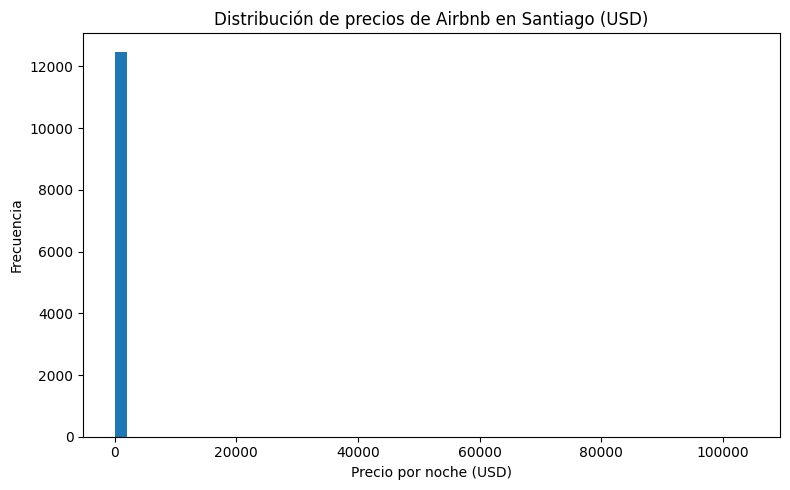

In [59]:
pdf_price = (
    listings_ml
    .select("price_usd")
    .dropna()
    .toPandas()
)

plt.figure(figsize=(8, 5))
plt.hist(pdf_price["price_usd"], bins=50)
plt.xlabel("Precio por noche (USD)")
plt.ylabel("Frecuencia")
plt.title("Distribución de precios de Airbnb en Santiago (USD)")
plt.tight_layout()
plt.show()

### 5.2 Top barrios por número de anuncios

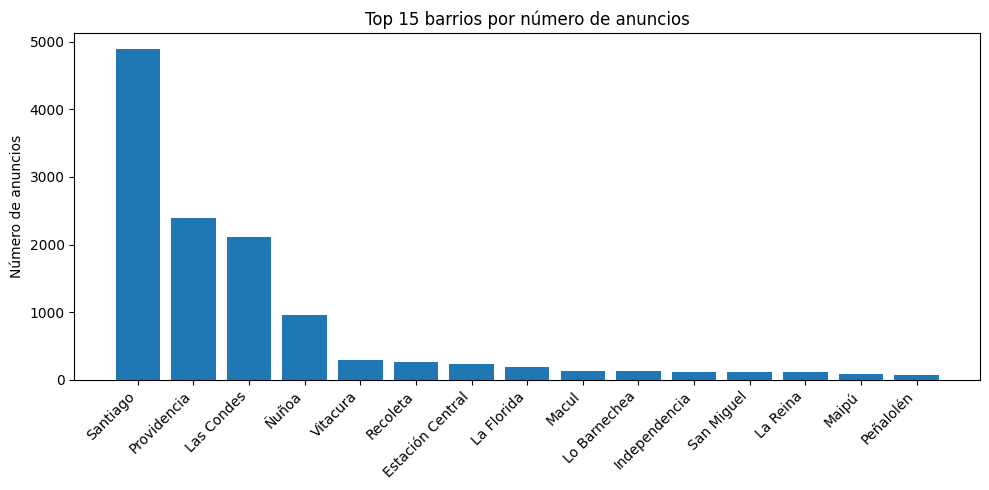

In [60]:
neigh_counts_pdf = (
    listings_ml
    .groupBy("neighbourhood")
    .count()
    .orderBy(F.col("count").desc())
    .limit(15)
    .toPandas()
)

plt.figure(figsize=(10, 5))
plt.bar(neigh_counts_pdf["neighbourhood"], neigh_counts_pdf["count"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Número de anuncios")
plt.title("Top 15 barrios por número de anuncios")
plt.tight_layout()
plt.show()

### 5.3. Relación precio vs ocupación

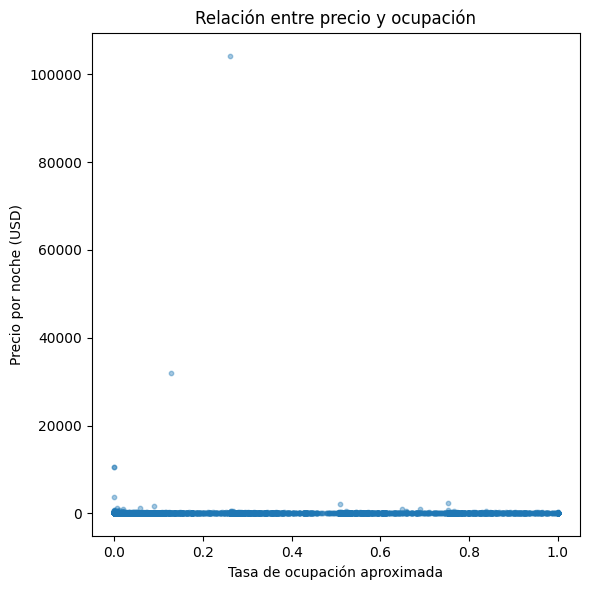

In [61]:
price_occ_pdf = (
    listings_ml
    .select("price_usd", "occupancy_rate")
    .dropna()
    .sample(False, 0.5, seed=42)   # muestra el 50% para que el gráfico no sea tan pesado
    .toPandas()
)

plt.figure(figsize=(6, 6))
plt.scatter(
    price_occ_pdf["occupancy_rate"],
    price_occ_pdf["price_usd"],
    alpha=0.4,
    s=10
)
plt.xlabel("Tasa de ocupación aproximada")
plt.ylabel("Precio por noche (USD)")
plt.title("Relación entre precio y ocupación")
plt.tight_layout()
plt.show()

### 5.4. Mapa de clusters de demanda (K-Means)

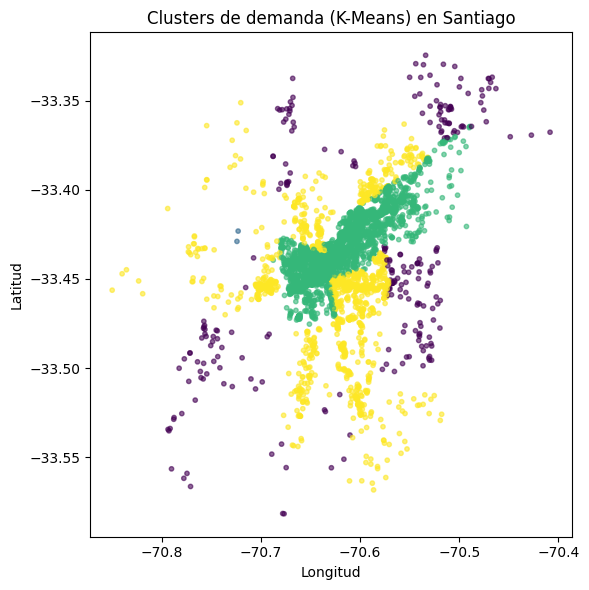

In [62]:
clusters_pdf = (
    listings_ml
    .select("latitude", "longitude", "demand_cluster")
    .dropna()
    .sample(False, 0.5, seed=42)
    .toPandas()
)

plt.figure(figsize=(6, 6))
plt.scatter(
    clusters_pdf["longitude"],
    clusters_pdf["latitude"],
    c=clusters_pdf["demand_cluster"],
    s=10,
    alpha=0.6
)
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.title("Clusters de demanda (K-Means) en Santiago")
plt.tight_layout()
plt.show()

### 5.5. Perfil de cada cluster (precio y ocupación medios)

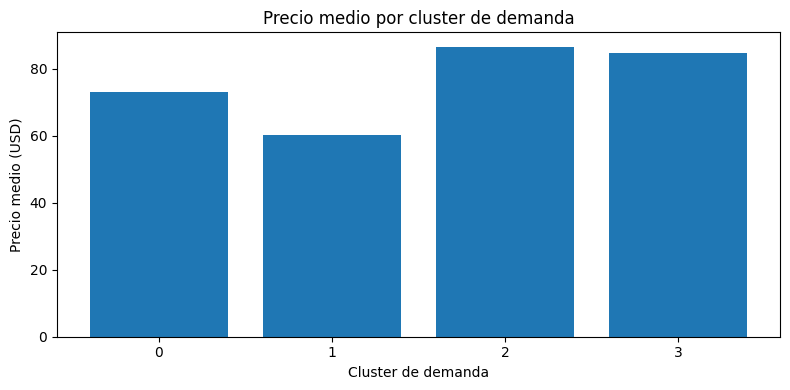

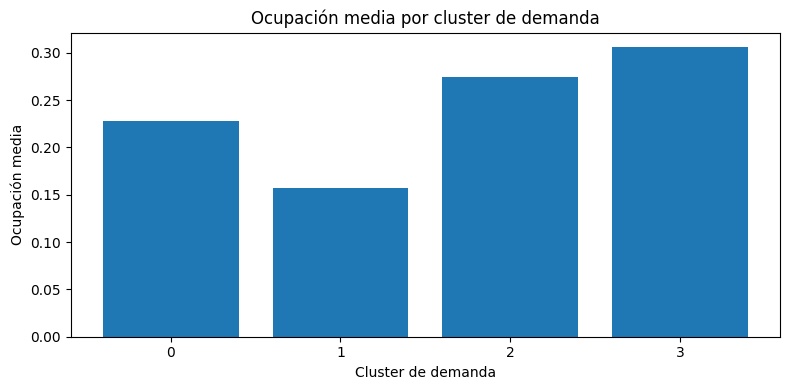

In [63]:
zones_summary_pdf = zones_summary.toPandas()

# Precio medio por cluster
plt.figure(figsize=(8, 4))
plt.bar(
    zones_summary_pdf["demand_cluster"].astype(str),
    zones_summary_pdf["cluster_avg_price_usd"]
)
plt.xlabel("Cluster de demanda")
plt.ylabel("Precio medio (USD)")
plt.title("Precio medio por cluster de demanda")
plt.tight_layout()
plt.show()

# Ocupación media por cluster
plt.figure(figsize=(8, 4))
plt.bar(
    zones_summary_pdf["demand_cluster"].astype(str),
    zones_summary_pdf["cluster_avg_occupancy_rate"]
)
plt.xlabel("Cluster de demanda")
plt.ylabel("Ocupación media")
plt.title("Ocupación media por cluster de demanda")
plt.tight_layout()
plt.show()

### 5.6. Importancia de variables (Random Forest)

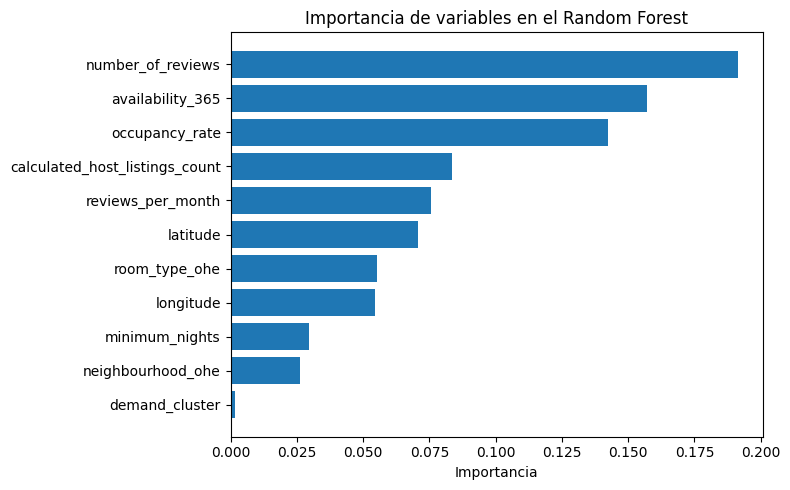

In [64]:
imp_pdf = (
    imp_df
    .orderBy(F.col("importance").desc())
    .toPandas()
)

plt.figure(figsize=(8, 5))
plt.barh(imp_pdf["feature"], imp_pdf["importance"])
plt.gca().invert_yaxis()  # para que la más importante quede arriba
plt.xlabel("Importancia")
plt.title("Importancia de variables en el Random Forest")
plt.tight_layout()
plt.show()

### 5.7. Precio real vs predicho (Random Forest)

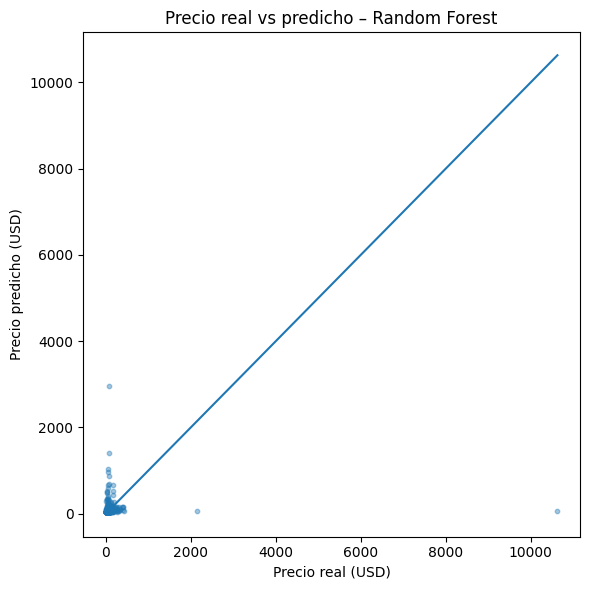

In [65]:
pred_rf_pdf = (
    pred_rf
    .select("price_usd", "prediction")
    .dropna()
    .sample(False, 0.5, seed=42)
    .toPandas()
)

plt.figure(figsize=(6, 6))
plt.scatter(
    pred_rf_pdf["price_usd"],
    pred_rf_pdf["prediction"],
    alpha=0.4,
    s=10
)

max_val = max(pred_rf_pdf["price_usd"].max(), pred_rf_pdf["prediction"].max())
plt.plot([0, max_val], [0, max_val])  # línea y = x para referencia

plt.xlabel("Precio real (USD)")
plt.ylabel("Precio predicho (USD)")
plt.title("Precio real vs predicho – Random Forest")
plt.tight_layout()
plt.show()

### 5.8 Histograma de errores del modelo

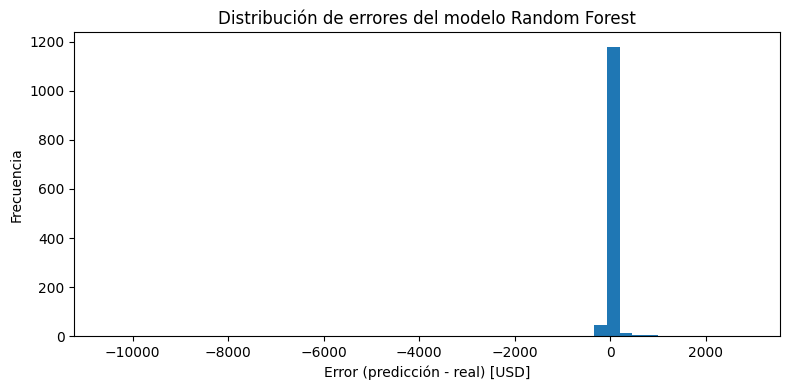

In [66]:
# 5.8 Histograma de errores (predicción - real)

pred_rf_pdf["error"] = pred_rf_pdf["prediction"] - pred_rf_pdf["price_usd"]

plt.figure(figsize=(8, 4))
plt.hist(pred_rf_pdf["error"], bins=50)
plt.xlabel("Error (predicción - real) [USD]")
plt.ylabel("Frecuencia")
plt.title("Distribución de errores del modelo Random Forest")
plt.tight_layout()
plt.show()

## 6. Power Bi